## **LIWC Turn-Level Analysis Pipeline**

This notebook analyzes turn-level LIWC output from negotiation transcripts.

**Data structure:** Each row is a speech segment (turn/utterance) with a `speaker` label (e.g., buyer = `b`, dealer = `d`) and LIWC features.

We run the analysis in five parts:

**Part A — Baseline differences:** Compare buyer vs dealer on LIWC variables.  
**Part B — Dynamics:** Plot how key variables evolve over turns (Segment).  
**Part C — Indices:** Build theory-guided composite indices (power, emotion pressure, cognitive defense, relational framing).  
**Part D — Reciprocity:** Test whether language at turn *t* predicts counterpart language at turn *t+1*.  
**Part E — Outcomes (not yet):** Based on price/timestamp/outcome, connects LIWC to final outcomes.


In [105]:
import arviz as az
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [106]:
# Make the figures a little smaller so we fit more on the screen
plt.rcParams["figure.dpi"] = 75
plt.rcParams["figure.figsize"] = (6.4, 3.2)

In [107]:
# Change the way NumPy 2.0 displays floats
np.set_printoptions(legacy="1.25")

In [108]:
# Load CSV
df = pd.read_csv("20240528.csv")

# Display datafram
df.head()

,id,speaker,text,Segment,WC,Analytic,Clout,Authentic,Tone,WPS,...,socbehav,prosocial,polite,conflict,moral,comm,time,focuspast,focuspresent,focusfuture
0,1,d,"Hey Tommy, this is Glen from Toyota. How are y...",1,11,1.50,99.00,5.07,NaN,5.50,...,9.09,0.00,0,0,0.0,9.09,0.0,0.0,18.18,0.00
1,2,b,"Hey man, I'm doing well. I'm hoping you can he...",1,49,27.39,1.00,78.40,99.0,16.33,...,4.08,2.04,0,0,0.0,2.04,0.0,0.0,10.20,6.12
2,3,d,Where are you driving from?,1,5,3.80,99.00,99.00,NaN,5.00,...,0.00,0.00,0,0,0.0,0.00,0.0,0.0,20.00,0.00
3,4,b,San Diego. I'm in San Diego right now.,1,8,26.10,1.71,99.00,NaN,4.00,...,0.00,0.00,0,0,0.0,0.00,12.5,0.0,25.00,0.00
4,5,d,Got it. So the Arizona store is giving you a c...,1,12,26.10,98.75,NaN,NaN,6.00,...,0.00,0.00,0,0,0.0,0.00,0.0,0.0,8.33,0.00


In [109]:
# Create turn_id per speaker within each id
df["turn_id"] = (df.groupby(["speaker"]).cumcount() + 1)

# Display the first few rows of specific columns
display(df[['speaker', 'turn_id']].head())

,speaker,turn_id
0,d,1
1,b,1
2,d,2
3,b,2
4,d,3


In [110]:
df.shape

(23, 50)

## **Part A: Baseline differences (buyer vs dealer)**

Establish whether the buyer and dealer have different linguistic "styles" on average.
- For each LIWC variable, compute and compare group means/std by `speaker`
- Compare prob density charts using Arviz
- Run Welch's t-test (robust to unequal variance)

#### **Variable blocks based on LIWC-22 Manual, 2022**
#### **Block 1: Structural variables**
*   WC: Total number of words in the text.
*   WPS – Average number of words per sentence, reflecting syntactic length.
#### **Block 2: Summary variables**
*   Analytic – Composite score reflecting formal, logical, and hierarchical thinking style.
*   Clout – Composite score indicating social status, confidence, or dominance in language.
*   Authentic – Composite score reflecting honesty, personal disclosure, and self-revelation.
*   Tone – Composite index representing overall emotional valence balance.
#### **Block 3: Motivational drives**
*   Drives – Overall proportion of words reflecting motivational needs.
*   affiliation – Words related to social bonding and connection motives.
*   achieve – Words reflecting achievement striving and goal pursuit.
*   power – Words related to dominance, control, and influence motives.
#### **Block 4: Cognitive processing**
*   Cognition – Overall proportion of cognitive process words.
*   allnone – Words reflecting absolute or all-or-nothing thinking.
*   cogproc – Cognitive mechanism words indicating thinking processes.
*   insight – Words signaling realization or understanding.
*   discrep – Words reflecting discrepancy or comparison between states.
*   tentat – Words expressing tentativeness or uncertainty.
*   certitude – Words expressing certainty or conviction.
*   differ – Words indicating differentiation or contrast.
*   memory – Words referencing remembering or recalling past events.
#### **Block 5: Affect/emotion**
*   Affect – Overall proportion of affective or emotion words.
*   tone_pos – Percentage of positive emotional tone words.
*   tone_neg – Percentage of negative emotional tone words.
*   emotion – General category of emotion words.
*   emo_pos – Words expressing positive emotions.
*   emo_neg – Words expressing negative emotions.
*   emo_anx – Words specifically related to anxiety or worry.
*   emo_anger – Words expressing anger or hostility.
*   emo_sad – Words reflecting sadness or grief.
#### **Block 6: Social/relational**
*   Social – Overall proportion of social process words.
*   socbehav – Words describing social behaviors or interactions.
*   prosocial – Words reflecting cooperation, helping, or positive social intent.
*   polite – Words signaling politeness or courtesy.
*   conflict – Words indicating disagreement, hostility, or confrontation.
*   moral – Words referencing moral values or ethical judgments.
*   comm – Words referring to communication acts.
#### **Block 7: Time orientation**
*   time – General time-related words.
*   focuspast – Words referring to past events.
*   focuspresent – Words focused on present events or states.
*   focusfuture – Words referring to future events or plans.

In [111]:
# Drop text, speaker, id, and segment
stats = df.columns.drop(['text', 'speaker', 'id', 'Segment', 'turn_id'])

# Comparison of Mean and Std for 'b' and 'd'
comparison = df.groupby('speaker', observed=False)[stats].agg(['mean', 'std']).T

print("Comparison: Buyer (b) vs Dealer (d)")
display(comparison)

Comparison: Buyer (b) vs Dealer (d)


speaker                    b          d
WC           mean  16.363636  12.833333
             std   13.851157  14.173171
Analytic     mean  31.021000  11.576000
             std   28.083091  16.765251
Clout        mean  23.669091  64.873750
...                      ...        ...
focuspast    std    5.913331   2.486758
focuspresent mean  10.277273  11.530833
             std   10.766391   7.769913
focusfuture  mean   2.567273   2.445833
             std    4.602706   7.211968

[90 rows x 2 columns]

In [112]:
# Welch's t-test
from scipy.stats import ttest_ind

def welch_ttests(df, vars_, group_col="speaker", g1="b", g2="d", min_n=2):
    rows = []
    for v in (set(vars_) & set(df.columns)):
        a = df.loc[df[group_col] == g1, v].dropna()
        b = df.loc[df[group_col] == g2, v].dropna()
        if len(a) >= min_n and len(b) >= min_n:
            t, p = ttest_ind(a, b, equal_var=False, nan_policy="omit")
            rows.append((v, a.mean(), b.mean(), t, p, len(a), len(b)))
    return pd.DataFrame(rows, columns=["Variable","Buyer_Mean","Dealer_Mean","t_stat","p_value","n_buyer","n_dealer"])

# run
res = welch_ttests(df, stats).sort_values("p_value").reset_index(drop=True)
display(res)

,Variable,Buyer_Mean,Dealer_Mean,t_stat,p_value,n_buyer,n_dealer
0,i,12.577273,2.957500,3.031707,0.008017,11,12
1,Clout,23.669091,64.873750,-2.167890,0.050506,11,8
2,Analytic,31.021000,11.576000,1.880053,0.080078,10,10
3,we,0.000000,0.780833,-1.832657,0.094036,11,12
4,time,1.136364,5.035833,-1.419686,0.175760,11,12
5,certitude,1.304545,0.000000,1.366837,0.201616,11,12
6,affiliation,0.185455,0.780833,-1.281271,0.219589,11,12
7,allnone,1.515455,0.180833,1.263031,0.233644,11,12
8,prosocial,0.884545,0.000000,1.254464,0.238201,11,12
9,you,2.399091,4.876667,-1.133513,0.271270,11,12


###**Baseline differences: Visualization**

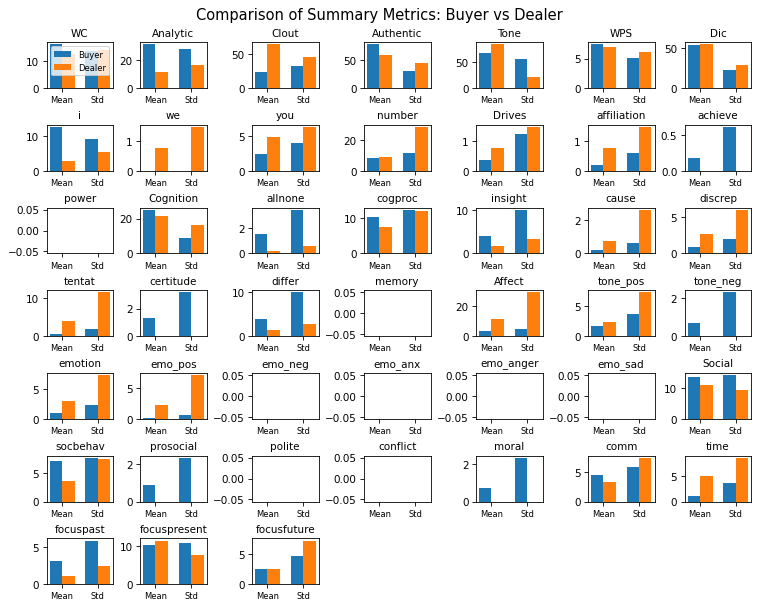

In [113]:
fig, axes = plt.subplots(7, 7, figsize=(10, 8), constrained_layout=True)
axes = axes.flatten()

for i, var in enumerate(stats):
    b_data = df[df['speaker'] == 'b'][var].dropna()
    d_data = df[df['speaker'] == 'd'][var].dropna()

    # Calculate stats
    means = [b_data.mean(), d_data.mean()]
    stds = [b_data.std(), d_data.std()]

    x = np.arange(2) # Mean, Std
    width = 0.35

    axes[i].bar(x - width/2, [means[0], stds[0]], width, label='Buyer', color='C0')
    axes[i].bar(x + width/2, [means[1], stds[1]], width, label='Dealer', color='C1')

    axes[i].set_title(var, fontsize=10)
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(['Mean', 'Std'], fontsize=8)
    if i == 0: axes[i].legend(fontsize=8)

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle('Comparison of Summary Metrics: Buyer vs Dealer', fontsize=14)
plt.show()

### ArviZ Density Plots

These plots (created via `az.plot_dist`) show the **Estimated Probability Density** for each group:

1.  **Overlap:** Where the blue (Buyer) and orange (Dealer) areas overlap, the groups behave similarly.
2.  **Peaks (Modes):** The highest point of the curve indicates the most common value for that speaker. For example, if the Dealer peak is further to the right on 'Clout', they consistently use more high-status language.
3.  **Spread (Variance):** A wider, flatter curve suggests that the speaker's style varies significantly across turns. A narrow, tall peak suggests a very consistent linguistic style.
4.  **Specific Insights:**
    *   **Analytic:** Compare if one party is more logical/formal vs. narrative.
    *   **Clout:** Identify who maintains higher social presence or confidence.
    *   **Authentic:** See who is more self-disclosing or 'raw' in their speech.
    *   **Tone:** Check for differences in emotional valence (positivity vs. negativity).

/usr/local/lib/python3.12/dist-packages/arviz/stats/density_utils.py:488: UserWarning: Your data appears to have a single value or no finite values
  warnings.warn("Your data appears to have a single value or no finite values")


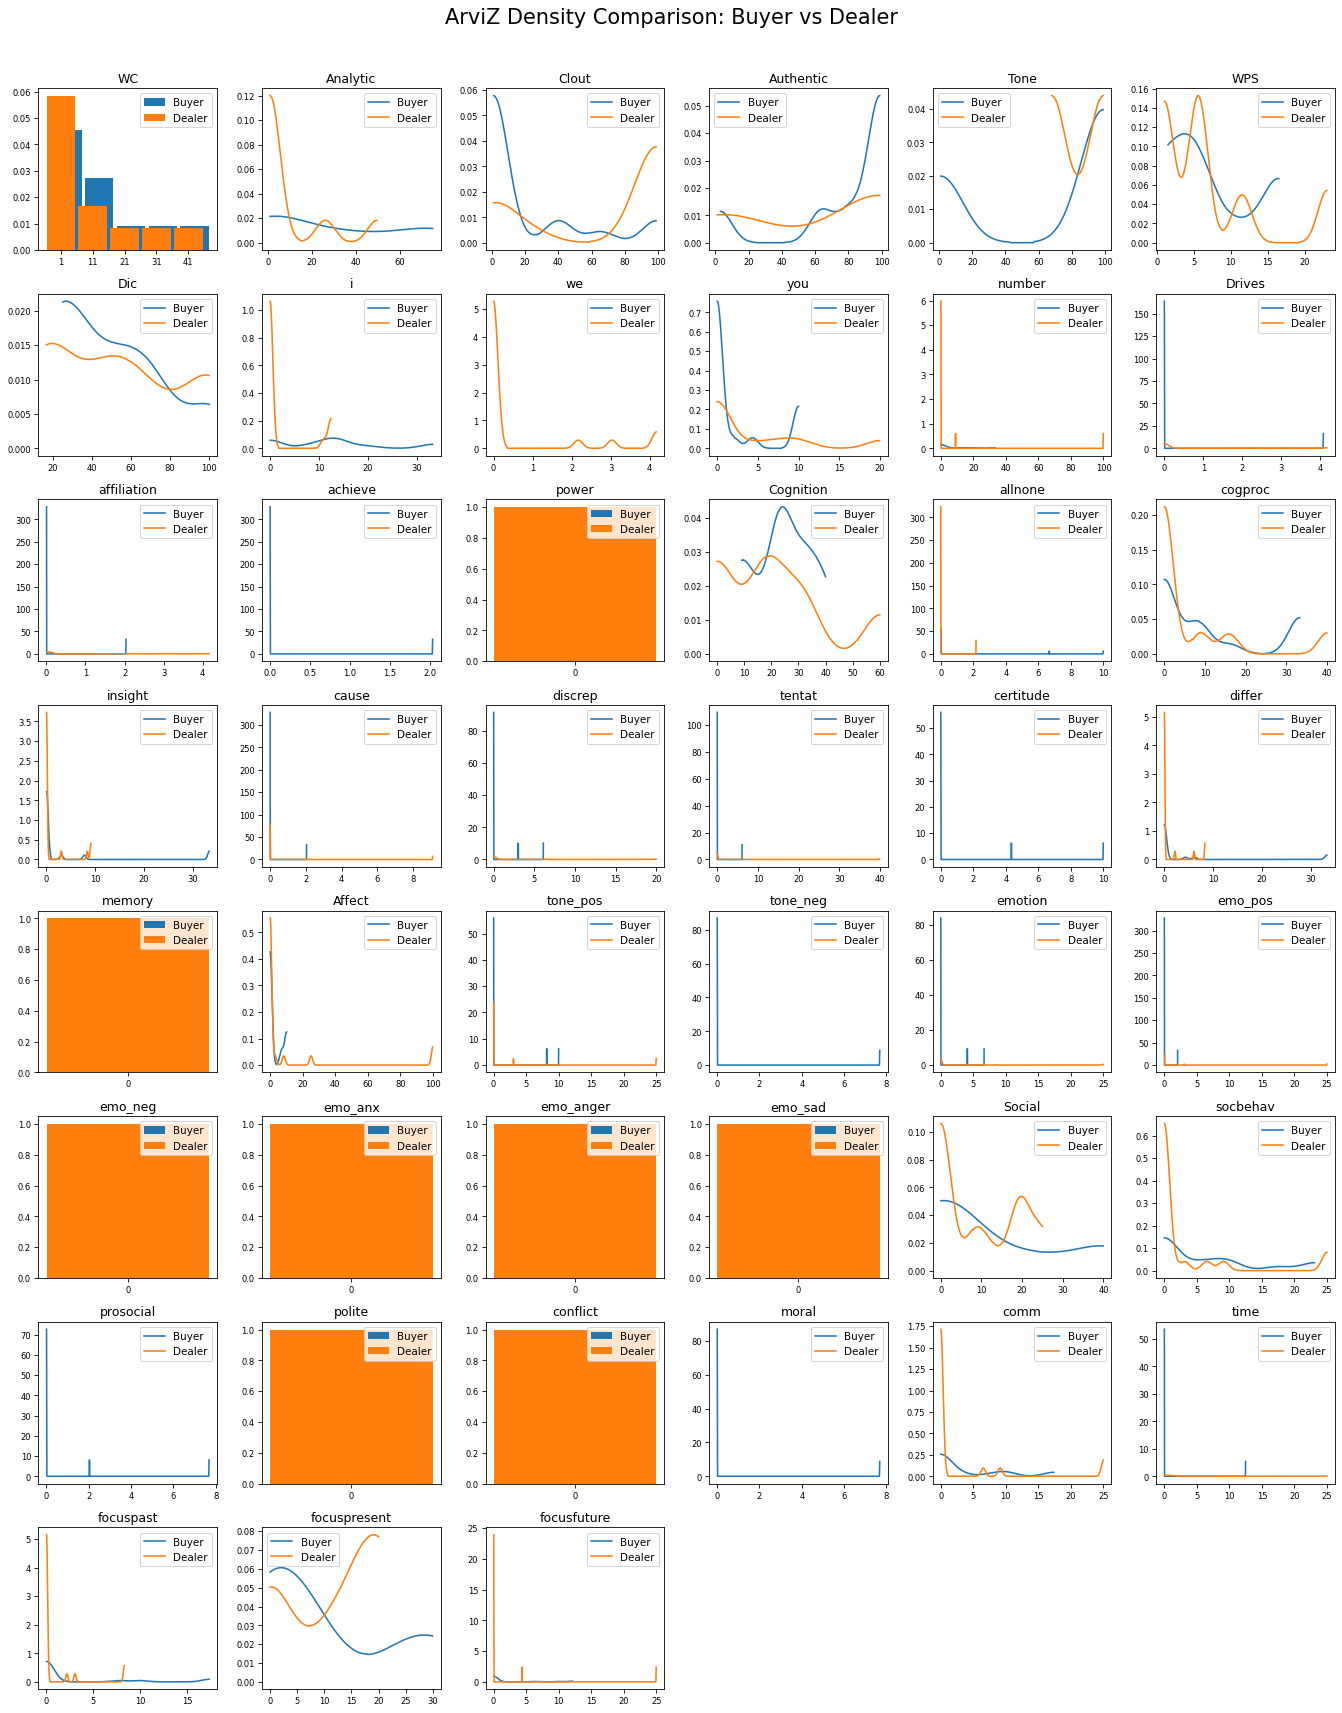

In [114]:
stats = df.columns.drop(['text', 'speaker', 'id', 'Segment', 'turn_id'])

# Dictionary of arrays grouped by speaker
data_dict = {
    var: {
        "buyer": df[df['speaker'] == 'b'][var].dropna().values,
        "dealer": df[df['speaker'] == 'd'][var].dropna().values
    } for var in stats
}

# Calculate dimensions
n_vars = len(stats)
cols = 6
rows = (n_vars // cols) + (1 if n_vars % cols > 0 else 0)

# Create a density plot with significantly larger figure size
fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 3))
axes = axes.flatten()

for i, var in enumerate(stats):
    az.plot_dist(data_dict[var]["buyer"], ax=axes[i], color="C0", label="Buyer")
    az.plot_dist(data_dict[var]["dealer"], ax=axes[i], color="C1", label="Dealer")
    axes[i].set_title(var, fontsize=12)
    axes[i].tick_params(axis='both', which='major', labelsize=8)
    if i == 0:
        axes[i].legend(fontsize=10)

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.suptitle("ArviZ Density Comparison: Buyer vs Dealer", fontsize=20)
plt.show()

####**Baseline Differences: Group-level**

In [115]:
# Customize Blocks
blocks = {

    "block1_structural": ["WC", "WPS"],

    "block2_time": [
        "time", "focuspast", "focuspresent", "focusfuture"]
}

In [116]:
from scipy import stats as sp_stats

# Welch t-test
def baseline_comparison(block_vars):
    results = []

    for var in block_vars:
        if var not in df.columns:
            continue

        b_vals = df[df["speaker"] == "b"][var].dropna()
        d_vals = df[df["speaker"] == "d"][var].dropna()

        if len(b_vals) > 1 and len(d_vals) > 1:
            # Use sp_stats to avoid conflict with the 'stats' variable
            t_stat, p_val = sp_stats.ttest_ind(b_vals, d_vals, equal_var=False)

            results.append({
                "Variable": var,
                "Buyer_Mean": b_vals.mean(),
                "Dealer_Mean": d_vals.mean(),
                "t_stat": t_stat,
                "p_value": p_val
            })

    return pd.DataFrame(results)

# Run for each block
baseline_results = {}

for block_name, vars_list in blocks.items():
    baseline_results[block_name] = baseline_comparison(vars_list)

# Display results for verification
for name, res_df in baseline_results.items():
    print(f"\nResults for {name}:")
    display(res_df)


Results for block1_structural:


,Variable,Buyer_Mean,Dealer_Mean,t_stat,p_value
0,WC,16.363636,12.833333,0.603835,0.552451
1,WPS,7.378182,6.958333,0.178845,0.859783



Results for block2_time:


,Variable,Buyer_Mean,Dealer_Mean,t_stat,p_value
0,time,1.136364,5.035833,-1.419686,0.175760
1,focuspast,3.189091,1.127500,1.072612,0.302678
2,focuspresent,10.277273,11.530833,-0.317701,0.754351
3,focusfuture,2.567273,2.445833,0.048536,0.961800


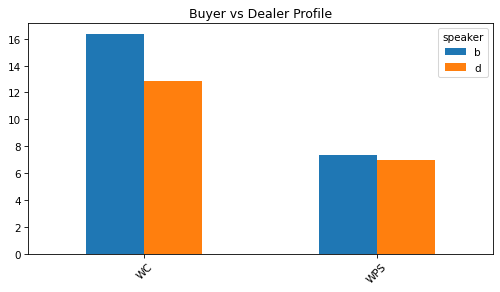

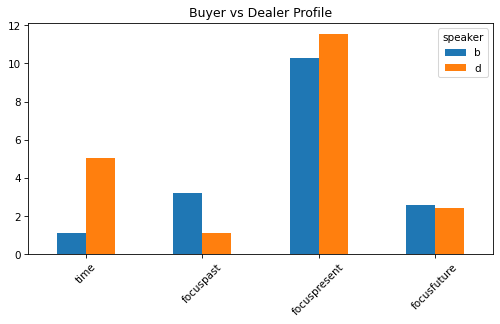

In [117]:
def radar_plot(block_vars):

    mean_vals = df.groupby("speaker")[block_vars].mean()

    mean_vals.T.plot(kind="bar", figsize=(8,4))
    plt.title("Buyer vs Dealer Profile")
    plt.xticks(rotation=45)
    plt.show()

radar_plot(blocks["block1_structural"])
radar_plot(blocks["block2_time"])

###**Part B — Dynamics: Key variable changes over turns for buyer and dealer.**  

In [118]:
# List of vars
# Descriptive: WC and WPS
# Summary: Analytic, Clout, Authentic, and Tone.
# Motivation: Drives, affiliation, achieve, and power.
# Cognitive: Cognition, allnone, cogproc, insight, discrep, tentat, certitude, differ, and memory.
# Affect/emotion: Affect, tone_pos, tone_neg, emotion, emo_pos, emo_neg, emo_anx,emo_anger, and emo_sad.
# Social/relational: Social, socbehav, prosocial, polite, conflict, moral, and comm.
# Time: time, focuspast, focuspresent, and focusfuture.

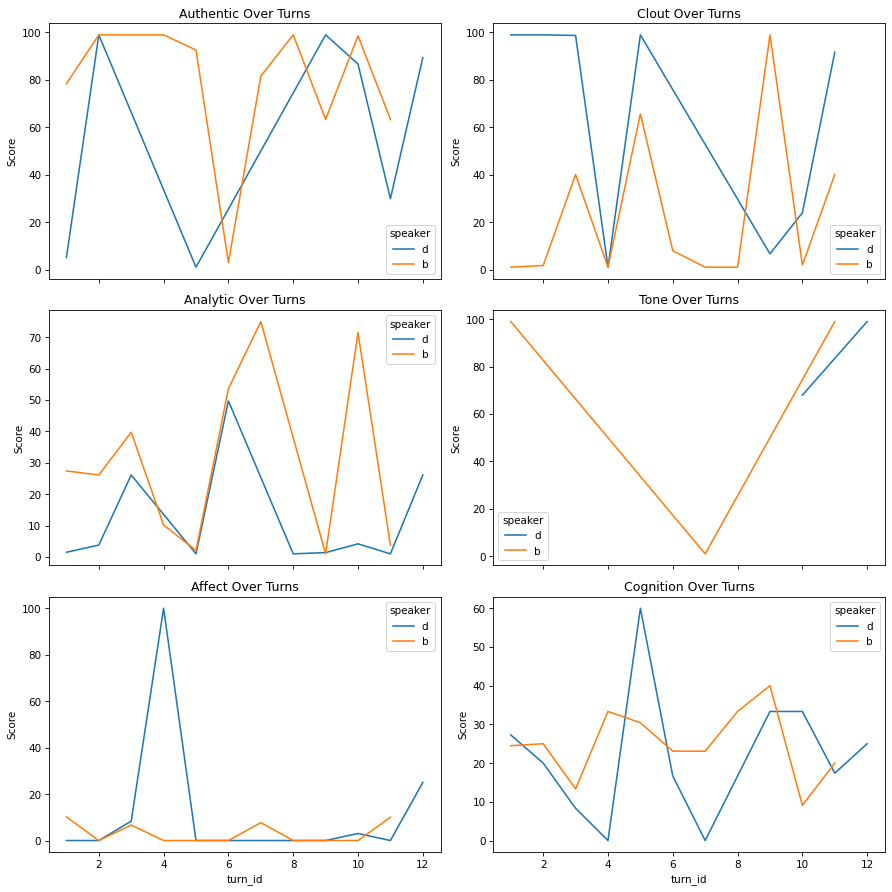

In [119]:
# Trajectory of 6 Key Variables
plot_vars = ["Authentic", "Clout", "Analytic", "Tone", "Affect", "Cognition"]
fig, axes = plt.subplots(3, 2, figsize=(12, 12), sharex=True)
axes = axes.flatten()

for i, var in enumerate(plot_vars):
    sns.lineplot(data=df, x="turn_id", y=var, hue="speaker", ax=axes[i])
    axes[i].set_title(f"{var} Over Turns")
    axes[i].set_ylabel("Score")

plt.tight_layout()
plt.show()

### **Part C — Indices: Theory-guided composite indices (power, emotion pressure, cognitive defense, relational framing).**

In [120]:
# Power Projection Index
df["Power_Index"] = (
    df["Clout"] +
    df["power"] +
    df["certitude"] -
    df["tentat"]
)

In [121]:
# Emotional Pressure Index
df["Emotional_Pressure"] = (
    df["emo_anger"] +
    df["emo_neg"] +
    df["conflict"]
)

In [122]:
# Cognitive Defense Index
df["Cognitive_Defense"] = (
    df["insight"] +
    df["cause"] +
    df["discrep"] +
    df["tentat"] +
    df["differ"]
)

In [123]:
# Relational Framing Index
df["Relational_Index"] = (
    df["affiliation"] +
    df["prosocial"] +
    df["polite"] +
    df["we"]
)

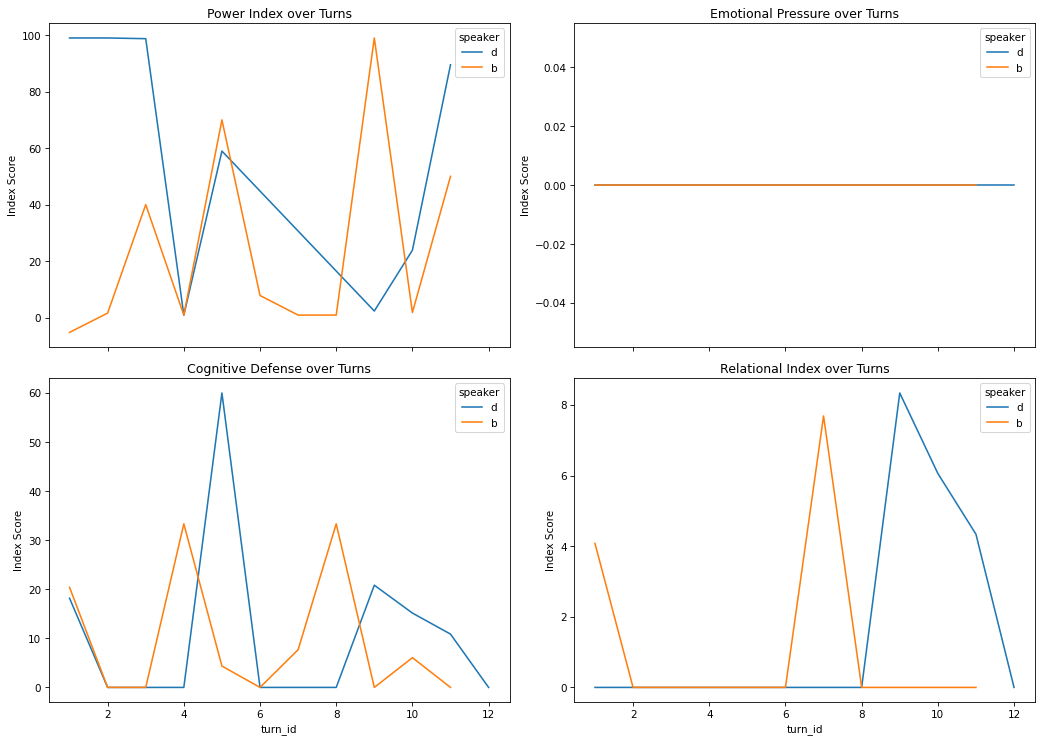

In [124]:
# Plot Composite Indices Dynamics
index_vars = ['Power_Index', 'Emotional_Pressure', 'Cognitive_Defense', 'Relational_Index']
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)
axes = axes.flatten()

for i, var in enumerate(index_vars):
    if var in df.columns:
        sns.lineplot(data=df, x='turn_id', y=var, hue='speaker', ax=axes[i])
        axes[i].set_title(f'{var.replace("_", " ")} over Turns')
        axes[i].set_ylabel('Index Score')
    else:
        axes[i].text(0.5, 0.5, f'{var} not found in DataFrame', ha='center')

plt.tight_layout()
plt.show()

### **Part D — Reciprocity: Whether language at turn *t* predicts counterpart language at turn *t+1*.**

In [125]:
# Create lagged variables within each conversation ID
df["Authentic_lag"] = df.groupby("id")["Authentic"].shift(1)
df["Clout_lag"] = df.groupby("id")["Clout"].shift(1)

# Prepare data for regression: Focus on Dealer turns where we have a lagged Buyer turn
# We drop NaNs to avoid the 'zero-size array' error
regression_data = df[(df["speaker"] == "d")].dropna(subset=["Clout", "Authentic_lag"])

if not regression_data.empty:
    # Example: Does buyer anger in the previous turn predict dealer clout in the current turn?
    model = smf.ols("Clout ~ Authentic_lag", data=regression_data).fit()
    print(model.summary())
else:
    print("Error: Not enough overlapping data points to run the regression. Check if 'id' or 'turn_id' segments are sufficient.")

Error: Not enough overlapping data points to run the regression. Check if 'id' or 'turn_id' segments are sufficient.
